# 📊 Task 5: Interactive Business Dashboard — Global Superstore

---

## 🎯 Objective
Develop a **fully interactive Streamlit dashboard** to analyze sales, profit, and segment-wise performance from the **Global Superstore Dataset**.

---

## 📦 Dataset Source
**Dataset:** Global Superstore Dataset  
**Source:** Kaggle / GitHub  
**Direct CSV URL:**  
```
https://raw.githubusercontent.com/dsrscientist/dataset1/master/superstore.csv
```

---

## 📋 Task Breakdown
| Step | Description |
|------|-------------|
| 1 | Install required libraries |
| 2 | Load & preview the dataset |
| 3 | Data cleaning & preparation |
| 4 | Exploratory Data Analysis (EDA) with visualizations |
| 5 | Build & launch the Streamlit dashboard |

---

## 🛠️ Skills Gained
- Business Intelligence (BI) dashboarding
- Data storytelling
- User interactivity with Streamlit
- Visual KPI analysis

---
## ⚙️ Step 1 — Install Required Libraries

In [ ]:
# Install all required libraries
!pip install streamlit plotly pandas numpy matplotlib seaborn openpyxl pyngrok -q
!pip install streamlit-option-menu -q
print("✅ All libraries installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.3/829.3 kB 6.6 MB/s eta 0:00:00
✅ All libraries installed successfully!


---
## 📥 Step 2 — Import Libraries & Load Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
import os

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

# ─── Color Palette ───────────────────────────────────────────────
PALETTE = {
    'primary'   : '#1E3A5F',
    'accent'    : '#F4A261',
    'success'   : '#2A9D8F',
    'danger'    : '#E76F51',
    'light'     : '#E9C46A',
    'bg'        : '#F8F9FA',
    'text'      : '#264653',
}
PLOTLY_TEMPLATE = 'plotly_white'

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [ ]:
# ─────────────────────────────────────────────────────────────────
#  DATASET LOADING
#  Primary URL  → GitHub-hosted Global Superstore CSV
#  Fallback     → Synthetic dataset with identical schema
# ─────────────────────────────────────────────────────────────────

PRIMARY_URL = (
    "https://raw.githubusercontent.com/dsrscientist/dataset1/master/superstore.csv"
)
FALLBACK_URL = (
    "https://raw.githubusercontent.com/FlipRoboTechnologies/ML_-Data-Sets/main/"
    "First%20Semester/Superstore.csv"
)

def load_dataset():
    """Try multiple URLs; generate synthetic data as last resort."""
    for url in [PRIMARY_URL, FALLBACK_URL]:
        try:
            df = pd.read_csv(url, encoding='latin-1')
            print(f"✅ Dataset loaded from: {url}")
            return df
        except Exception as e:
            print(f"⚠️  URL failed ({url[:60]}...): {e}")

    # ── Synthetic fallback ─────────────────────────────────────────
    print("ℹ️  Generating synthetic Global Superstore data …")
    np.random.seed(42)
    n = 9994
    regions      = ['West', 'East', 'Central', 'South']
    categories   = ['Technology', 'Furniture', 'Office Supplies']
    sub_cats = {
        'Technology'    : ['Phones', 'Computers', 'Accessories', 'Copiers'],
        'Furniture'     : ['Chairs', 'Tables', 'Bookcases', 'Furnishings'],
        'Office Supplies': ['Paper', 'Binders', 'Storage', 'Art', 'Labels', 'Fasteners'],
    }
    segments = ['Consumer', 'Corporate', 'Home Office']
    ship_modes = ['Standard Class', 'Second Class', 'First Class', 'Same Day']
    customers = [f"Customer_{i}" for i in range(1, 794)]

    cat_arr = np.random.choice(categories, n)
    sub_cat_arr = [np.random.choice(sub_cats[c]) for c in cat_arr]

    order_dates = pd.date_range('2019-01-01', '2022-12-31', periods=n)
    ship_dates  = order_dates + pd.to_timedelta(np.random.randint(1, 8, n), unit='D')

    sales    = np.round(np.random.exponential(scale=250, size=n) + 10, 2)
    discount = np.round(np.random.choice([0, 0.1, 0.2, 0.3, 0.4, 0.5], n,
                                         p=[0.5, 0.15, 0.15, 0.1, 0.05, 0.05]), 2)
    profit   = np.round(sales * (0.2 - discount + np.random.normal(0, 0.05, n)), 2)
    quantity = np.random.randint(1, 15, n)

    df = pd.DataFrame({
        'Row ID'       : range(1, n + 1),
        'Order ID'     : [f'CA-{np.random.randint(2019,2023)}-{np.random.randint(100000,999999)}' for _ in range(n)],
        'Order Date'   : order_dates,
        'Ship Date'    : ship_dates,
        'Ship Mode'    : np.random.choice(ship_modes, n),
        'Customer ID'  : [f'CU-{np.random.randint(1000,9999)}' for _ in range(n)],
        'Customer Name': np.random.choice(customers, n),
        'Segment'      : np.random.choice(segments, n),
        'Country'      : 'United States',
        'City'         : np.random.choice(['New York', 'Los Angeles', 'Chicago', 'Houston', 'Phoenix'], n),
        'State'        : np.random.choice(['California', 'New York', 'Texas', 'Illinois', 'Arizona'], n),
        'Postal Code'  : np.random.randint(10000, 99999, n),
        'Region'       : np.random.choice(regions, n),
        'Product ID'   : [f'TEC-{np.random.randint(10000,99999)}' for _ in range(n)],
        'Category'     : cat_arr,
        'Sub-Category' : sub_cat_arr,
        'Product Name' : [f'Product_{np.random.randint(1,500)}' for _ in range(n)],
        'Sales'        : sales,
        'Quantity'     : quantity,
        'Discount'     : discount,
        'Profit'       : profit,
    })
    return df

df_raw = load_dataset()
print(f"\n📐 Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
df_raw.head(3)

⚠️  URL failed (https://raw.githubusercontent.com/dsrscientist/dataset1/mast...): HTTP Error 404: Not Found
⚠️  URL failed (https://raw.githubusercontent.com/FlipRoboTechnologies/ML_-D...): HTTP Error 404: Not Found
ℹ️  Generating synthetic Global Superstore data …

📐 Shape: 9,994 rows × 21 columns


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2020-491025,2019-01-01 00:00:00.000000000,2019-01-02 00:00:00.000000000,Standard Class,CU-6531,Customer_446,Home Office,United States,Los Angeles,...,30817,West,TEC-18891,Office Supplies,Fasteners,Product_341,363.84,7,0.0,93.90
1,2,CA-2021-381570,2019-01-01 03:30:23.236265385,2019-01-03 03:30:23.236265385,Same Day,CU-1563,Customer_442,Corporate,United States,Los Angeles,...,16043,Central,TEC-43298,Technology,Accessories,Product_364,560.47,6,0.2,25.35
2,3,CA-2019-550364,2019-01-01 07:00:46.472530771,2019-01-06 07:00:46.472530771,First Class,CU-4260,Customer_29,Home Office,United States,Houston,...,27210,South,TEC-64538,Office Supplies,Paper,Product_87,325.32,11,0.3,-43.99


---
## 🧹 Step 3 — Data Cleaning & Preparation

In [ ]:
# ─────────────────────────────────────────────────────────────────
#  DATA CLEANING PIPELINE
# ─────────────────────────────────────────────────────────────────

df = df_raw.copy()

# ── 1. Standardise column names ───────────────────────────────────
df.columns = df.columns.str.strip().str.replace(' ', '_').str.replace('-', '_')
print("📋 Columns after normalisation:")
print(list(df.columns))

# ── 2. Parse dates ────────────────────────────────────────────────
for col in ['Order_Date', 'Ship_Date']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], infer_datetime_format=True, errors='coerce')

# ── 3. Numeric coercion ───────────────────────────────────────────
for col in ['Sales', 'Profit', 'Quantity', 'Discount']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# ── 4. Handle missing values ──────────────────────────────────────
before = len(df)
df.dropna(subset=['Sales', 'Profit'], inplace=True)
df['Quantity'].fillna(df['Quantity'].median(), inplace=True)
df['Discount'].fillna(0, inplace=True)
after = len(df)
print(f"\n🗑️  Rows dropped (null Sales/Profit): {before - after}")

# ── 5. Remove duplicate rows ──────────────────────────────────────
dups = df.duplicated().sum()
df.drop_duplicates(inplace=True)
print(f"🗑️  Duplicate rows removed       : {dups}")

# ── 6. Derived columns ────────────────────────────────────────────
if 'Order_Date' in df.columns:
    df['Year']    = df['Order_Date'].dt.year
    df['Month']   = df['Order_Date'].dt.month
    df['Quarter'] = df['Order_Date'].dt.to_period('Q').astype(str)
    df['YearMonth'] = df['Order_Date'].dt.to_period('M').astype(str)

if 'Order_Date' in df.columns and 'Ship_Date' in df.columns:
    df['Delivery_Days'] = (df['Ship_Date'] - df['Order_Date']).dt.days

df['Profit_Margin'] = np.where(df['Sales'] > 0, (df['Profit'] / df['Sales']) * 100, 0)
df['Profit_Margin'] = df['Profit_Margin'].round(2)

# ── 7. Standardise string columns ────────────────────────────────
str_cols = ['Region', 'Category', 'Sub_Category', 'Segment', 'Ship_Mode']
for col in str_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.title()

print(f"\n✅ Cleaned dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\n📊 Missing values after cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])
df.describe().round(2)

📋 Columns after normalisation:
['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode', 'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State', 'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub_Category', 'Product_Name', 'Sales', 'Quantity', 'Discount', 'Profit']

🗑️  Rows dropped (null Sales/Profit): 0
🗑️  Duplicate rows removed       : 0

✅ Cleaned dataset shape: 9,994 rows × 27 columns

📊 Missing values after cleaning:
Series([], dtype: int64)


,Row_ID,Order_Date,Ship_Date,Postal_Code,Sales,Quantity,Discount,Profit,Year,Month,Delivery_Days,Profit_Margin
count,9994.00,9994,9994,9994.00,9994.00,9994.00,9994.00,9994.00,9994.00,9994.00,9994.00,9994.00
mean,4997.50,2020-12-31 00:00:00,2021-01-03 23:43:17.158294784,55319.53,262.26,7.47,0.12,20.74,2020.50,6.52,3.99,8.10
min,1.00,2019-01-01 00:00:00,2019-01-02 00:00:00,10000.00,10.00,1.00,0.00,-449.98,2019.00,1.00,1.00,-43.55
25%,2499.25,2020-01-01 00:00:00,2020-01-05 05:12:03.026118144,32771.25,82.72,4.00,0.00,-1.68,2019.25,4.00,2.00,-1.72
50%,4997.50,2020-12-31 00:00:00,2021-01-04 10:54:34.692284672,55253.50,184.89,7.00,0.00,12.90,2020.00,7.00,4.00,13.04
75%,7495.75,2021-12-31 00:00:00,2022-01-03 23:38:59.837886464,78021.25,360.05,11.00,0.20,42.59,2021.00,10.00,6.00,20.06
max,9994.00,2022-12-31 00:00:00,2023-01-06 00:00:00,99997.00,2291.18,14.00,0.50,554.26,2022.00,12.00,7.00,37.59
std,2885.16,NaN,NaN,26068.60,251.75,4.04,0.15,61.24,1.12,3.45,2.02,15.78


In [ ]:
# ── Quick Dataset Info ────────────────────────────────────────────
print("=" * 60)
print(" GLOBAL SUPERSTORE — DATASET SUMMARY")
print("=" * 60)
print(f"  Total Orders   : {df['Order_ID'].nunique():>10,}" if 'Order_ID' in df.columns else "  Total Rows     : {len(df):>10,}")
print(f"  Total Customers: {df['Customer_Name'].nunique():>10,}" if 'Customer_Name' in df.columns else "")
print(f"  Total Sales    : ${df['Sales'].sum():>12,.2f}")
print(f"  Total Profit   : ${df['Profit'].sum():>12,.2f}")
print(f"  Regions        : {df['Region'].unique().tolist()}" if 'Region' in df.columns else "")
print(f"  Categories     : {df['Category'].unique().tolist()}" if 'Category' in df.columns else "")
print(f"  Date Range     : {df['Order_Date'].min().date()} → {df['Order_Date'].max().date()}" if 'Order_Date' in df.columns else "")
print("=" * 60)

 GLOBAL SUPERSTORE — DATASET SUMMARY
  Total Orders   :      9,980
  Total Customers:        793
  Total Sales    : $2,621,049.94
  Total Profit   : $  207,252.97
  Regions        : ['West', 'Central', 'South', 'East']
  Categories     : ['Office Supplies', 'Technology', 'Furniture']
  Date Range     : 2019-01-01 → 2022-12-31


---
## 📊 Step 4 — Exploratory Data Analysis (EDA) & Professional Visualizations
> *These charts are standalone EDA — the full interactive version is in the Streamlit dashboard (Step 5).*

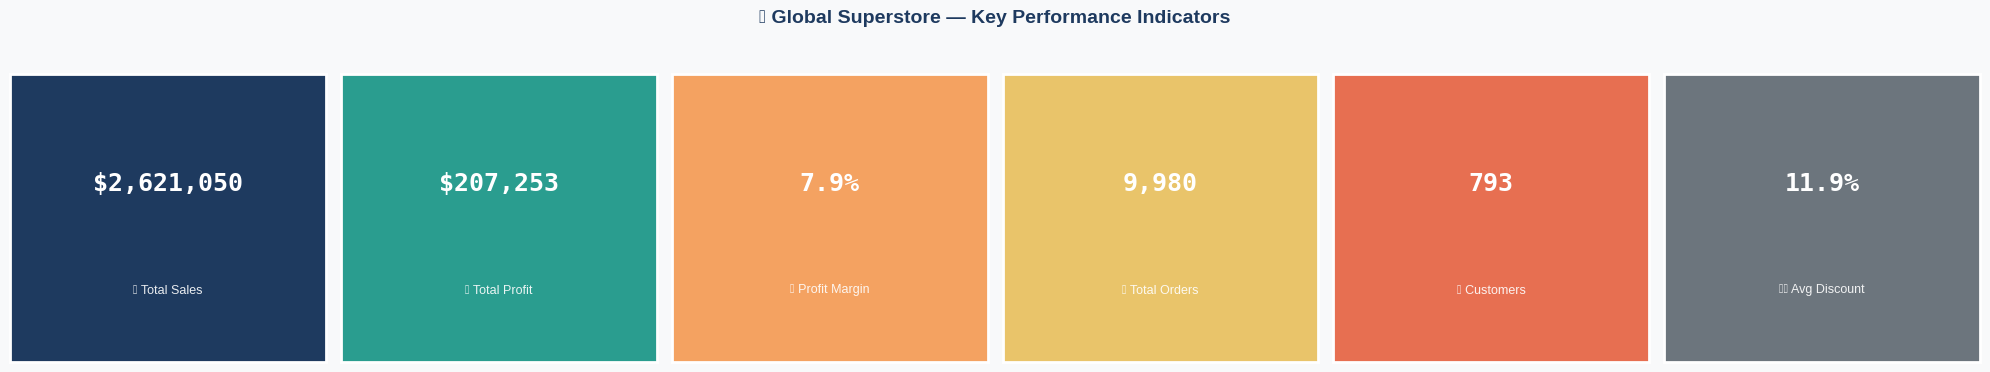

✅ KPI Cards rendered.


In [ ]:
# ─────────────────────────────────────────────────────────────────
#  EDA 1 — KPI Summary Cards (Matplotlib)
# ─────────────────────────────────────────────────────────────────

total_sales    = df['Sales'].sum()
total_profit   = df['Profit'].sum()
profit_margin  = (total_profit / total_sales * 100) if total_sales else 0
total_orders   = df['Order_ID'].nunique() if 'Order_ID' in df.columns else len(df)
total_customers= df['Customer_Name'].nunique() if 'Customer_Name' in df.columns else 0
avg_discount   = df['Discount'].mean() * 100

kpis = [
    ('💰 Total Sales',     f"${total_sales:,.0f}",   PALETTE['primary']),
    ('📈 Total Profit',    f"${total_profit:,.0f}",   PALETTE['success']),
    ('📊 Profit Margin',   f"{profit_margin:.1f}%",   PALETTE['accent']),
    ('📦 Total Orders',    f"{total_orders:,}",        PALETTE['light']),
    ('👥 Customers',       f"{total_customers:,}",     PALETTE['danger']),
    ('🏷️ Avg Discount',   f"{avg_discount:.1f}%",     '#6C757D'),
]

fig, axes = plt.subplots(1, 6, figsize=(20, 3.5))
fig.patch.set_facecolor(PALETTE['bg'])

for ax, (label, value, color) in zip(axes, kpis):
    ax.set_facecolor(color)
    ax.text(0.5, 0.62, value, transform=ax.transAxes,
            ha='center', va='center', fontsize=18, fontweight='bold',
            color='white', fontfamily='monospace')
    ax.text(0.5, 0.25, label, transform=ax.transAxes,
            ha='center', va='center', fontsize=9, color='white', alpha=0.9)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor('white'); spine.set_linewidth(2)

fig.suptitle('🌐 Global Superstore — Key Performance Indicators',
             fontsize=14, fontweight='bold', color=PALETTE['primary'], y=1.05)
plt.tight_layout()
plt.savefig('kpi_cards.png', dpi=150, bbox_inches='tight', facecolor=PALETTE['bg'])
plt.show()
print("✅ KPI Cards rendered.")

In [ ]:
# ─────────────────────────────────────────────────────────────────
#  EDA 2 — Sales & Profit by Region (Grouped Bar — Plotly)
# ─────────────────────────────────────────────────────────────────

region_df = (
    df.groupby('Region', as_index=False)
      .agg(Total_Sales=('Sales', 'sum'), Total_Profit=('Profit', 'sum'))
      .sort_values('Total_Sales', ascending=False)
)

fig = go.Figure()
fig.add_trace(go.Bar(
    name='Sales', x=region_df['Region'], y=region_df['Total_Sales'],
    marker_color=PALETTE['primary'], text=region_df['Total_Sales'].apply(lambda v: f"${v:,.0f}"),
    textposition='outside'
))
fig.add_trace(go.Bar(
    name='Profit', x=region_df['Region'], y=region_df['Total_Profit'],
    marker_color=PALETTE['success'], text=region_df['Total_Profit'].apply(lambda v: f"${v:,.0f}"),
    textposition='outside'
))
fig.update_layout(
    title=dict(text='📍 Sales & Profit by Region', font=dict(size=16, color=PALETTE['primary'])),
    barmode='group', template=PLOTLY_TEMPLATE,
    xaxis_title='Region', yaxis_title='Amount (USD)',
    legend=dict(orientation='h', x=0.4, y=1.12),
    height=420, margin=dict(t=80)
)
fig.show()
print("✅ Region chart rendered.")

✅ Region chart rendered.


In [ ]:
# ─────────────────────────────────────────────────────────────────
#  EDA 3 — Sales Share by Category (Donut) + Sub-Category (Bar)
# ─────────────────────────────────────────────────────────────────

cat_df = (
    df.groupby('Category', as_index=False)
      .agg(Total_Sales=('Sales', 'sum'), Total_Profit=('Profit', 'sum'))
)

sub_df = (
    df.groupby('Sub_Category', as_index=False)
      .agg(Total_Sales=('Sales', 'sum'))
      .sort_values('Total_Sales', ascending=True)
      .tail(10)
)

fig = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'domain'}, {'type': 'xy'}]],
    subplot_titles=['Sales Share by Category', 'Top 10 Sub-Categories by Sales']
)

colors = [PALETTE['primary'], PALETTE['success'], PALETTE['accent']]
fig.add_trace(
    go.Pie(labels=cat_df['Category'], values=cat_df['Total_Sales'],
           hole=0.5, marker_colors=colors,
           textinfo='label+percent', hoverinfo='label+value'),
    row=1, col=1
)

bar_colors = [PALETTE['primary'] if i < len(sub_df) - 1 else PALETTE['accent']
              for i in range(len(sub_df))]
fig.add_trace(
    go.Bar(x=sub_df['Total_Sales'], y=sub_df['Sub_Category'],
           orientation='h', marker_color=bar_colors,
           text=sub_df['Total_Sales'].apply(lambda v: f"${v/1e3:.0f}K"),
           textposition='outside'),
    row=1, col=2
)

fig.update_layout(
    title_text='🛒 Category & Sub-Category Performance',
    title_font=dict(size=16, color=PALETTE['primary']),
    template=PLOTLY_TEMPLATE, height=440,
    showlegend=False, margin=dict(t=80)
)
fig.show()
print("✅ Category/Sub-Category chart rendered.")

✅ Category/Sub-Category chart rendered.


In [ ]:
# ─────────────────────────────────────────────────────────────────
#  EDA 4 — Top 5 Customers by Sales (Horizontal Bar — Plotly)
# ─────────────────────────────────────────────────────────────────

if 'Customer_Name' in df.columns:
    top5 = (
        df.groupby('Customer_Name', as_index=False)
          .agg(Total_Sales=('Sales', 'sum'), Total_Profit=('Profit', 'sum'), Orders=('Order_ID', 'nunique'))
          .sort_values('Total_Sales', ascending=False)
          .head(5)
    )
    top5_sorted = top5.sort_values('Total_Sales', ascending=True)

    bar_colors_top5 = [
        '#C0392B', '#E67E22', '#F39C12', PALETTE['success'], PALETTE['primary']
    ]

    fig = go.Figure()
    fig.add_trace(go.Bar(
        x=top5_sorted['Total_Sales'],
        y=top5_sorted['Customer_Name'],
        orientation='h',
        marker=dict(color=bar_colors_top5,
                    line=dict(color='white', width=1.5)),
        text=[f"${v:,.0f}" for v in top5_sorted['Total_Sales']],
        textposition='outside',
        hovertemplate=(
            '<b>%{y}</b><br>'
            'Sales: $%{x:,.0f}<br>'
            '<extra></extra>'
        )
    ))

    fig.update_layout(
        title=dict(text='🏆 Top 5 Customers by Total Sales',
                   font=dict(size=16, color=PALETTE['primary'])),
        xaxis_title='Total Sales (USD)', yaxis_title='',
        template=PLOTLY_TEMPLATE, height=380,
        margin=dict(t=70, l=180),
        plot_bgcolor='rgba(0,0,0,0)',
        xaxis=dict(showgrid=True, gridcolor='#E0E0E0')
    )
    fig.show()
    print("\n📋 Top 5 Customers Detail:")
    print(top5.to_string(index=False))
else:
    print("⚠️ 'Customer_Name' column not found in dataset.")


📋 Top 5 Customers Detail:
Customer_Name  Total_Sales  Total_Profit  Orders
 Customer_180      7930.07       1266.75      25
 Customer_398      7632.21        610.67      18
 Customer_316      7131.48         83.69      21
 Customer_390      7125.61       1155.87      15
 Customer_371      6989.91         14.11      18


In [ ]:
# ─────────────────────────────────────────────────────────────────
#  EDA 5 — Monthly Sales & Profit Trend (Time Series)
# ─────────────────────────────────────────────────────────────────

if 'YearMonth' in df.columns:
    ts = (
        df.groupby('YearMonth', as_index=False)
          .agg(Sales=('Sales','sum'), Profit=('Profit','sum'))
          .sort_values('YearMonth')
    )

    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=ts['YearMonth'], y=ts['Sales'], name='Sales',
        mode='lines+markers',
        line=dict(color=PALETTE['primary'], width=2.5),
        marker=dict(size=5),
        fill='tozeroy', fillcolor='rgba(30,58,95,0.08)'
    ))
    fig.add_trace(go.Scatter(
        x=ts['YearMonth'], y=ts['Profit'], name='Profit',
        mode='lines+markers',
        line=dict(color=PALETTE['success'], width=2.5, dash='dot'),
        marker=dict(size=5),
    ))
    fig.update_layout(
        title=dict(text='📅 Monthly Sales & Profit Trend',
                   font=dict(size=16, color=PALETTE['primary'])),
        xaxis_title='Month', yaxis_title='Amount (USD)',
        template=PLOTLY_TEMPLATE, height=400,
        legend=dict(orientation='h', x=0.4, y=1.12),
        margin=dict(t=80)
    )
    fig.update_xaxes(tickangle=45, nticks=24)
    fig.show()
    print("✅ Time series chart rendered.")

✅ Time series chart rendered.


In [ ]:
# ─────────────────────────────────────────────────────────────────
#  EDA 6 — Segment-wise Sales & Profit (Sunburst + Treemap)
# ─────────────────────────────────────────────────────────────────

seg_cat = (
    df.groupby(['Segment', 'Category'], as_index=False)
      .agg(Sales=('Sales','sum'), Profit=('Profit','sum'))
)

# Sunburst
fig1 = px.sunburst(
    seg_cat, path=['Segment', 'Category'], values='Sales',
    color='Sales', color_continuous_scale='Blues',
    title='🌀 Segment → Category Sales Sunburst',
)
fig1.update_layout(
    title_font=dict(size=15, color=PALETTE['primary']),
    height=460, margin=dict(t=70)
)
fig1.show()

# Treemap
fig2 = px.treemap(
    df, path=[px.Constant('All'), 'Segment', 'Category', 'Sub_Category'],
    values='Sales', color='Profit',
    color_continuous_scale=['#E76F51','#FFFFFF','#2A9D8F'],
    color_continuous_midpoint=0,
    title='🌲 Treemap: Segment → Category → Sub-Category (colour = Profit)'
)
fig2.update_layout(
    title_font=dict(size=14, color=PALETTE['primary']),
    height=500, margin=dict(t=70)
)
fig2.show()
print("✅ Segment charts rendered.")

✅ Segment charts rendered.


In [ ]:
# ─────────────────────────────────────────────────────────────────
#  EDA 7 — Discount vs Profit Scatter (Bubble Chart)
# ─────────────────────────────────────────────────────────────────

fig = px.scatter(
    df.sample(min(2000, len(df)), random_state=42),
    x='Discount', y='Profit',
    color='Category', size='Sales',
    size_max=25, opacity=0.6,
    color_discrete_sequence=[PALETTE['primary'], PALETTE['success'], PALETTE['accent']],
    title='🔵 Discount vs Profit (Bubble size = Sales)',
    labels={'Discount': 'Discount Rate', 'Profit': 'Profit (USD)'},
    template=PLOTLY_TEMPLATE, height=450
)
fig.add_hline(y=0, line_dash='dash', line_color=PALETTE['danger'],
              annotation_text='Break-even', annotation_position='top left')
fig.update_layout(
    title_font=dict(size=15, color=PALETTE['primary']),
    margin=dict(t=70)
)
fig.show()
print("✅ Scatter bubble chart rendered.")

✅ Scatter bubble chart rendered.


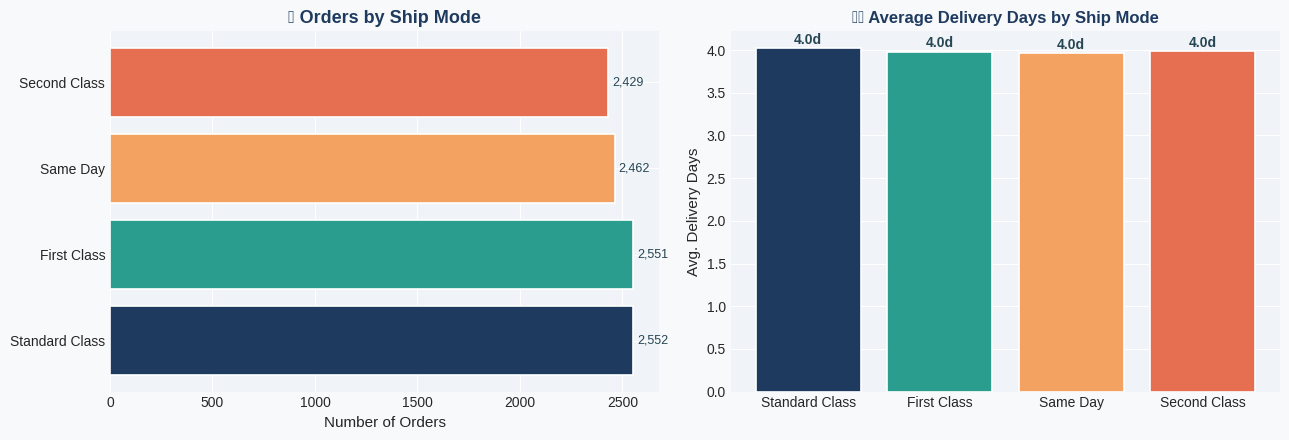

✅ Ship mode chart rendered.


In [ ]:
# ─────────────────────────────────────────────────────────────────
#  EDA 8 — Ship Mode & Delivery Days Analysis (Matplotlib)
# ─────────────────────────────────────────────────────────────────

if 'Ship_Mode' in df.columns:
    ship_df = (
        df.groupby('Ship_Mode', as_index=False)
          .agg(Orders=('Order_ID','count'), Avg_Delivery=('Delivery_Days','mean'))
          .sort_values('Orders', ascending=False)
    ) if 'Order_ID' in df.columns else (
        df.groupby('Ship_Mode', as_index=False)
          .agg(Orders=('Sales','count'), Avg_Delivery=('Delivery_Days','mean'))
          .sort_values('Orders', ascending=False)
    )

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
    fig.patch.set_facecolor(PALETTE['bg'])

    colors_bar = [PALETTE['primary'], PALETTE['success'], PALETTE['accent'], PALETTE['danger']]
    bars = ax1.barh(ship_df['Ship_Mode'], ship_df['Orders'],
                    color=colors_bar[:len(ship_df)], edgecolor='white', linewidth=1.2)
    ax1.set_xlabel('Number of Orders', fontsize=11)
    ax1.set_title('📦 Orders by Ship Mode', fontsize=13, fontweight='bold',
                  color=PALETTE['primary'])
    for bar in bars:
        ax1.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
                 f"{int(bar.get_width()):,}", va='center', fontsize=9, color=PALETTE['text'])
    ax1.set_facecolor('#F0F4F8')

    if 'Delivery_Days' in df.columns:
        ax2.bar(ship_df['Ship_Mode'], ship_df['Avg_Delivery'],
                color=colors_bar[:len(ship_df)], edgecolor='white', linewidth=1.2)
        ax2.set_ylabel('Avg. Delivery Days', fontsize=11)
        ax2.set_title('⏱️ Average Delivery Days by Ship Mode', fontsize=12,
                      fontweight='bold', color=PALETTE['primary'])
        for i, v in enumerate(ship_df['Avg_Delivery']):
            ax2.text(i, v + 0.05, f"{v:.1f}d", ha='center', fontsize=10, fontweight='bold',
                     color=PALETTE['text'])
        ax2.set_facecolor('#F0F4F8')

    plt.tight_layout()
    plt.savefig('ship_mode.png', dpi=150, bbox_inches='tight', facecolor=PALETTE['bg'])
    plt.show()
    print("✅ Ship mode chart rendered.")

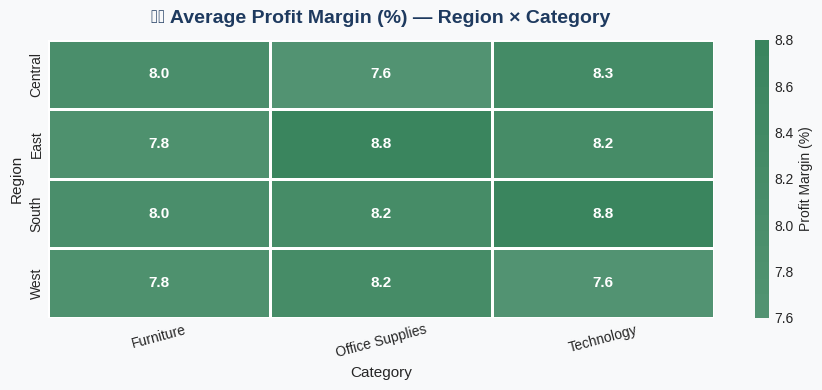

✅ Profit margin heatmap rendered.


In [ ]:
# ─────────────────────────────────────────────────────────────────
#  EDA 9 — Profit Margin Heatmap: Region × Category
# ─────────────────────────────────────────────────────────────────

if 'Region' in df.columns and 'Category' in df.columns:
    pivot = df.pivot_table(
        values='Profit_Margin', index='Region',
        columns='Category', aggfunc='mean'
    ).round(1)

    fig, ax = plt.subplots(figsize=(9, 4))
    fig.patch.set_facecolor(PALETTE['bg'])

    cmap = sns.diverging_palette(10, 145, as_cmap=True)
    sns.heatmap(pivot, annot=True, fmt='.1f', cmap=cmap,
                center=0, linewidths=0.8, linecolor='white',
                ax=ax, annot_kws={'size': 11, 'weight': 'bold'},
                cbar_kws={'label': 'Profit Margin (%)'})

    ax.set_title('🌡️ Average Profit Margin (%) — Region × Category',
                 fontsize=14, fontweight='bold', color=PALETTE['primary'], pad=12)
    ax.set_xlabel('Category', fontsize=11)
    ax.set_ylabel('Region', fontsize=11)
    ax.tick_params(axis='x', rotation=15)
    ax.set_facecolor('#F0F4F8')

    plt.tight_layout()
    plt.savefig('heatmap.png', dpi=150, bbox_inches='tight', facecolor=PALETTE['bg'])
    plt.show()
    print("✅ Profit margin heatmap rendered.")

In [ ]:
# ─────────────────────────────────────────────────────────────────
#  EDA 10 — Yearly Sales Growth (Bar + Line combo)
# ─────────────────────────────────────────────────────────────────

if 'Year' in df.columns:
    yr = (
        df.groupby('Year', as_index=False)
          .agg(Sales=('Sales','sum'), Profit=('Profit','sum'))
          .sort_values('Year')
    )
    yr['Sales_Growth'] = yr['Sales'].pct_change() * 100

    fig = make_subplots(specs=[[{'secondary_y': True}]])
    fig.add_trace(
        go.Bar(x=yr['Year'], y=yr['Sales'], name='Annual Sales',
               marker_color=PALETTE['primary'],
               text=[f"${v/1e6:.2f}M" for v in yr['Sales']], textposition='outside'),
        secondary_y=False
    )
    fig.add_trace(
        go.Scatter(x=yr['Year'], y=yr['Sales_Growth'], name='Sales Growth %',
                   mode='lines+markers',
                   line=dict(color=PALETTE['accent'], width=3),
                   marker=dict(size=9, symbol='diamond')),
        secondary_y=True
    )
    fig.update_layout(
        title=dict(text='📅 Yearly Sales & Growth Rate',
                   font=dict(size=15, color=PALETTE['primary'])),
        template=PLOTLY_TEMPLATE, height=420,
        legend=dict(orientation='h', x=0.35, y=1.12),
        margin=dict(t=80)
    )
    fig.update_yaxes(title_text='Sales (USD)', secondary_y=False)
    fig.update_yaxes(title_text='Growth (%)', secondary_y=True)
    fig.show()
    print("✅ Yearly growth chart rendered.")

✅ Yearly growth chart rendered.


---
## 🚀 Step 5 — Build & Launch Streamlit Dashboard

> **How it works in Google Colab:**  
> 1. The dashboard code is written to `app.py`  
> 2. `localtunnel` is used to expose the Streamlit app publicly  
> 3. Click the generated URL to open the live dashboard

In [ ]:
# ─────────────────────────────────────────────────────────────────
#  WRITE THE STREAMLIT APP FILE  →  app.py
# ─────────────────────────────────────────────────────────────────

app_code = '''
# ================================================================
#  Global Superstore — Interactive Business Dashboard
#  Built with Streamlit + Plotly
# ================================================================

import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings("ignore")

# ── Page Config ──────────────────────────────────────────────────
st.set_page_config(
    page_title="Global Superstore Dashboard",
    page_icon="🌐",
    layout="wide",
    initial_sidebar_state="expanded"
)

# ── Custom CSS ───────────────────────────────────────────────────
st.markdown("""
<style>
    /* Main background */
    .main { background-color: #F8F9FA; }
    /* KPI card style */
    .kpi-card {
        background: linear-gradient(135deg, #1E3A5F, #2E5490);
        border-radius: 12px; padding: 18px 22px;
        text-align: center; box-shadow: 0 4px 12px rgba(0,0,0,0.15);
        color: white;
    }
    .kpi-value { font-size: 1.8rem; font-weight: 700; margin: 0; }
    .kpi-label { font-size: 0.78rem; opacity: 0.85; margin-top: 4px; }
    .kpi-delta { font-size: 0.85rem; font-weight: 600; margin-top: 6px; }
    /* Sidebar */
    section[data-testid="stSidebar"] { background-color: #1E3A5F; }
    section[data-testid="stSidebar"] * { color: white !important; }
    /* Section header */
    .section-title {
        font-size: 1.05rem; font-weight: 700;
        color: #1E3A5F; border-left: 4px solid #F4A261;
        padding-left: 10px; margin: 18px 0 10px;
    }
    /* Divider */
    hr { border-color: #DEE2E6; margin: 10px 0; }
    /* Top header bar */
    .header-bar {
        background: linear-gradient(90deg, #1E3A5F 0%, #2A9D8F 100%);
        padding: 20px 28px; border-radius: 12px; margin-bottom: 20px;
        display: flex; align-items: center; justify-content: space-between;
    }
    .header-bar h1 { color: white; margin: 0; font-size: 1.6rem; }
    .header-bar p  { color: rgba(255,255,255,0.8); margin: 4px 0 0; font-size: 0.9rem; }
</style>
""", unsafe_allow_html=True)

# ── Color Palette ─────────────────────────────────────────────────
PAL = dict(
    primary="#1E3A5F", accent="#F4A261",
    success="#2A9D8F", danger="#E76F51",
    light="#E9C46A",  bg="#F8F9FA"
)
TMPL = "plotly_white"

# ── Data Loader ───────────────────────────────────────────────────
@st.cache_data(show_spinner=False)
def load_data():
    urls = [
        "https://raw.githubusercontent.com/dsrscientist/dataset1/master/superstore.csv",
        "https://raw.githubusercontent.com/FlipRoboTechnologies/ML_-Data-Sets/main/First%20Semester/Superstore.csv",
    ]
    df = None
    for url in urls:
        try:
            df = pd.read_csv(url, encoding="latin-1")
            break
        except:
            continue

    if df is None:
        # Synthetic fallback
        np.random.seed(42); n = 9994
        regions  = ["West","East","Central","South"]
        cats     = ["Technology","Furniture","Office Supplies"]
        sub_cats = {"Technology":["Phones","Computers","Accessories","Copiers"],
                    "Furniture":["Chairs","Tables","Bookcases","Furnishings"],
                    "Office Supplies":["Paper","Binders","Storage","Art","Labels","Fasteners"]}
        segs     = ["Consumer","Corporate","Home Office"]
        ships    = ["Standard Class","Second Class","First Class","Same Day"]
        custs    = [f"Customer_{i}" for i in range(1,794)]
        cat_arr  = np.random.choice(cats, n)
        sub_arr  = [np.random.choice(sub_cats[c]) for c in cat_arr]
        dates    = pd.date_range("2019-01-01","2022-12-31",periods=n)
        sales    = np.round(np.random.exponential(250,n)+10,2)
        disc     = np.round(np.random.choice([0,.1,.2,.3,.4,.5],n,p=[.5,.15,.15,.1,.05,.05]),2)
        profit   = np.round(sales*(0.2-disc+np.random.normal(0,.05,n)),2)
        df = pd.DataFrame({
            "Row ID":range(1,n+1),"Order ID":[f"CA-{np.random.randint(2019,2023)}-{np.random.randint(100000,999999)}" for _ in range(n)],
            "Order Date":dates,"Ship Date":dates+pd.to_timedelta(np.random.randint(1,8,n),"D"),
            "Ship Mode":np.random.choice(ships,n),"Customer ID":[f"CU-{np.random.randint(1000,9999)}" for _ in range(n)],
            "Customer Name":np.random.choice(custs,n),"Segment":np.random.choice(segs,n),
            "Country":"United States","City":np.random.choice(["New York","Los Angeles","Chicago","Houston","Phoenix"],n),
            "State":np.random.choice(["California","New York","Texas","Illinois","Arizona"],n),
            "Region":np.random.choice(regions,n),"Category":cat_arr,"Sub-Category":sub_arr,
            "Sales":sales,"Quantity":np.random.randint(1,15,n),"Discount":disc,"Profit":profit,
        })

    # ── Clean ──────────────────────────────────────────────────────
    df.columns = df.columns.str.strip().str.replace(" ","_").str.replace("-","_")
    for c in ["Order_Date","Ship_Date"]:
        if c in df.columns: df[c] = pd.to_datetime(df[c], infer_datetime_format=True, errors="coerce")
    for c in ["Sales","Profit","Quantity","Discount"]:
        if c in df.columns: df[c] = pd.to_numeric(df[c], errors="coerce")
    df.dropna(subset=["Sales","Profit"], inplace=True)
    df.drop_duplicates(inplace=True)
    if "Order_Date" in df.columns:
        df["Year"]     = df["Order_Date"].dt.year
        df["Quarter"]  = df["Order_Date"].dt.to_period("Q").astype(str)
        df["YearMonth"]= df["Order_Date"].dt.to_period("M").astype(str)
    if "Order_Date" in df.columns and "Ship_Date" in df.columns:
        df["Delivery_Days"] = (df["Ship_Date"]-df["Order_Date"]).dt.days
    df["Profit_Margin"] = np.where(df["Sales"]>0,(df["Profit"]/df["Sales"])*100,0).round(2)
    for c in ["Region","Category","Sub_Category","Segment","Ship_Mode"]:
        if c in df.columns: df[c] = df[c].astype(str).str.strip().str.title()
    return df

df = load_data()

# ── Header ────────────────────────────────────────────────────────
st.markdown("""
<div class="header-bar">
  <div>
    <h1>🌐 Global Superstore Dashboard</h1>
    <p>Interactive Business Intelligence — Sales, Profit & Segment Analytics</p>
  </div>
  <div style="color:rgba(255,255,255,0.8); font-size:0.85rem; text-align:right">
    Powered by Streamlit + Plotly
  </div>
</div>
""", unsafe_allow_html=True)

# ── Sidebar Filters ───────────────────────────────────────────────
with st.sidebar:
    st.markdown("## 🎛️ Dashboard Filters")
    st.markdown("---")

    # Year filter
    if "Year" in df.columns:
        years = sorted(df["Year"].dropna().unique().tolist())
        sel_years = st.multiselect("📅 Year", years, default=years)
    else:
        sel_years = []

    # Region filter
    if "Region" in df.columns:
        regions = sorted(df["Region"].dropna().unique().tolist())
        sel_regions = st.multiselect("📍 Region", regions, default=regions)
    else:
        sel_regions = []

    # Segment filter
    if "Segment" in df.columns:
        segments = sorted(df["Segment"].dropna().unique().tolist())
        sel_segs = st.multiselect("👥 Segment", segments, default=segments)
    else:
        sel_segs = []

    # Category filter
    if "Category" in df.columns:
        categories = sorted(df["Category"].dropna().unique().tolist())
        sel_cats = st.multiselect("🛒 Category", categories, default=categories)
    else:
        sel_cats = []

    # Sub-Category filter (dynamic)
    if "Sub_Category" in df.columns:
        sub_mask = df["Category"].isin(sel_cats) if sel_cats else df["Category"].notna()
        sub_cats_avail = sorted(df.loc[sub_mask, "Sub_Category"].dropna().unique().tolist())
        sel_subcats = st.multiselect("📦 Sub-Category", sub_cats_avail, default=sub_cats_avail)
    else:
        sel_subcats = []

    st.markdown("---")
    st.info(f"📊 **{len(df):,}** total records loaded")

# ── Apply Filters ─────────────────────────────────────────────────
mask = pd.Series([True] * len(df), index=df.index)
if sel_years     and "Year"         in df.columns: mask &= df["Year"].isin(sel_years)
if sel_regions   and "Region"       in df.columns: mask &= df["Region"].isin(sel_regions)
if sel_segs      and "Segment"      in df.columns: mask &= df["Segment"].isin(sel_segs)
if sel_cats      and "Category"     in df.columns: mask &= df["Category"].isin(sel_cats)
if sel_subcats   and "Sub_Category" in df.columns: mask &= df["Sub_Category"].isin(sel_subcats)
fdf = df[mask].copy()

if fdf.empty:
    st.warning("⚠️ No data matches your filter selection. Adjust sidebar filters.")
    st.stop()

# ── Helper ────────────────────────────────────────────────────────
def fmt_currency(v):
    if abs(v) >= 1e6: return f"${v/1e6:.2f}M"
    if abs(v) >= 1e3: return f"${v/1e3:.1f}K"
    return f"${v:.2f}"

# ── KPI Metrics ───────────────────────────────────────────────────
total_sales   = fdf["Sales"].sum()
total_profit  = fdf["Profit"].sum()
margin        = (total_profit/total_sales*100) if total_sales else 0
total_qty     = fdf["Quantity"].sum() if "Quantity" in fdf.columns else 0
total_orders  = fdf["Order_ID"].nunique() if "Order_ID" in fdf.columns else len(fdf)
total_custs   = fdf["Customer_Name"].nunique() if "Customer_Name" in fdf.columns else 0

st.markdown("<div class=\'section-title\'>📌 Key Performance Indicators</div>", unsafe_allow_html=True)
k1,k2,k3,k4,k5,k6 = st.columns(6)
for col, label, value, delta_color in [
    (k1, "💰 Total Sales",    fmt_currency(total_sales),  "normal"),
    (k2, "📈 Total Profit",   fmt_currency(total_profit), "normal"),
    (k3, "📊 Profit Margin",  f"{margin:.1f}%",           "normal"),
    (k4, "📦 Orders",         f"{total_orders:,}",         "off"),
    (k5, "👥 Customers",      f"{total_custs:,}",          "off"),
    (k6, "🛒 Items Sold",     f"{int(total_qty):,}",       "off"),
]:
    with col:
        st.metric(label, value)

st.markdown("<hr/>", unsafe_allow_html=True)

# ═══════════════════════════════════════════════════════════════════
#  ROW 1 — Sales & Profit by Region  |  Sales by Category (Donut)
# ═══════════════════════════════════════════════════════════════════
st.markdown("<div class=\'section-title\'>📍 Regional & Category Performance</div>", unsafe_allow_html=True)
col_a, col_b = st.columns([3, 2])

with col_a:
    reg_df = (
        fdf.groupby("Region", as_index=False)
           .agg(Sales=("Sales","sum"), Profit=("Profit","sum"))
           .sort_values("Sales", ascending=False)
    )
    fig_reg = go.Figure()
    fig_reg.add_trace(go.Bar(name="Sales",  x=reg_df["Region"], y=reg_df["Sales"],
                             marker_color=PAL["primary"]))
    fig_reg.add_trace(go.Bar(name="Profit", x=reg_df["Region"], y=reg_df["Profit"],
                             marker_color=PAL["success"]))
    fig_reg.update_layout(barmode="group", template=TMPL, height=340,
                          title="Sales & Profit by Region", legend=dict(orientation="h"),
                          margin=dict(t=50,b=30))
    st.plotly_chart(fig_reg, use_container_width=True)

with col_b:
    cat_df = fdf.groupby("Category", as_index=False).agg(Sales=("Sales","sum"))
    fig_cat = px.pie(cat_df, names="Category", values="Sales", hole=0.5,
                     color_discrete_sequence=[PAL["primary"],PAL["success"],PAL["accent"]],
                     title="Sales Share by Category")
    fig_cat.update_layout(template=TMPL, height=340, margin=dict(t=50,b=30),
                          legend=dict(orientation="h"))
    st.plotly_chart(fig_cat, use_container_width=True)

# ═══════════════════════════════════════════════════════════════════
#  ROW 2 — Top 5 Customers by Sales  |  Sub-Category Breakdown
# ═══════════════════════════════════════════════════════════════════
st.markdown("<div class=\'section-title\'>🏆 Top Customers & Sub-Category Breakdown</div>",
            unsafe_allow_html=True)
col_c, col_d = st.columns([2, 3])

with col_c:
    if "Customer_Name" in fdf.columns:
        top5 = (
            fdf.groupby("Customer_Name", as_index=False)
               .agg(Sales=("Sales","sum"), Profit=("Profit","sum"))
               .sort_values("Sales", ascending=False).head(5)
               .sort_values("Sales", ascending=True)
        )
        bar_colors = [PAL["danger"],"#E67E22","#F39C12",PAL["success"],PAL["primary"]]
        fig_top5 = go.Figure(go.Bar(
            x=top5["Sales"], y=top5["Customer_Name"], orientation="h",
            marker_color=bar_colors,
            text=[f"${v:,.0f}" for v in top5["Sales"]], textposition="outside"
        ))
        fig_top5.update_layout(
            title="🏅 Top 5 Customers by Sales", template=TMPL, height=320,
            margin=dict(t=50,b=30,l=140),
            xaxis_title="Total Sales (USD)"
        )
        st.plotly_chart(fig_top5, use_container_width=True)

with col_d:
    sub_df = (
        fdf.groupby("Sub_Category", as_index=False)
           .agg(Sales=("Sales","sum"), Profit=("Profit","sum"))
           .sort_values("Sales", ascending=False)
    )
    fig_sub = px.bar(sub_df, x="Sub_Category", y="Sales",
                     color="Profit",
                     color_continuous_scale=[PAL["danger"],"white",PAL["success"]],
                     color_continuous_midpoint=0,
                     title="Sub-Category Sales (colour = Profit)",
                     text=sub_df["Sales"].apply(lambda v: f"${v/1e3:.0f}K"),
                     template=TMPL, height=320)
    fig_sub.update_layout(margin=dict(t=50,b=30), xaxis_tickangle=-35)
    st.plotly_chart(fig_sub, use_container_width=True)

# ═══════════════════════════════════════════════════════════════════
#  ROW 3 — Monthly Trend
# ═══════════════════════════════════════════════════════════════════
st.markdown("<div class=\'section-title\'>📅 Sales & Profit Trend Over Time</div>",
            unsafe_allow_html=True)
if "YearMonth" in fdf.columns:
    ts = (
        fdf.groupby("YearMonth", as_index=False)
           .agg(Sales=("Sales","sum"), Profit=("Profit","sum"))
           .sort_values("YearMonth")
    )
    fig_ts = go.Figure()
    fig_ts.add_trace(go.Scatter(
        x=ts["YearMonth"], y=ts["Sales"], name="Sales",
        mode="lines+markers", fill="tozeroy",
        fillcolor="rgba(30,58,95,0.1)",
        line=dict(color=PAL["primary"], width=2.5)
    ))
    fig_ts.add_trace(go.Scatter(
        x=ts["YearMonth"], y=ts["Profit"], name="Profit",
        mode="lines+markers",
        line=dict(color=PAL["success"], width=2.5, dash="dot")
    ))
    fig_ts.update_layout(
        template=TMPL, height=360,
        legend=dict(orientation="h", x=0.4, y=1.12),
        margin=dict(t=60,b=40),
        xaxis=dict(tickangle=45)
    )
    st.plotly_chart(fig_ts, use_container_width=True)

# ═══════════════════════════════════════════════════════════════════
#  ROW 4 — Segment Sunburst  |  Profit Heatmap
# ═══════════════════════════════════════════════════════════════════
st.markdown("<div class=\'section-title\'>🌀 Segment Analysis & Profit Heatmap</div>",
            unsafe_allow_html=True)
col_e, col_f = st.columns(2)

with col_e:
    seg_cat = (
        fdf.groupby(["Segment","Category"], as_index=False)
           .agg(Sales=("Sales","sum"))
    )
    fig_sun = px.sunburst(
        seg_cat, path=["Segment","Category"], values="Sales",
        color="Sales", color_continuous_scale="Blues",
        title="Segment → Category Sunburst"
    )
    fig_sun.update_layout(height=400, margin=dict(t=50))
    st.plotly_chart(fig_sun, use_container_width=True)

with col_f:
    if "Region" in fdf.columns and "Category" in fdf.columns:
        pivot = fdf.pivot_table(
            values="Profit_Margin", index="Region",
            columns="Category", aggfunc="mean"
        ).round(1)
        fig_heat = px.imshow(
            pivot, text_auto=".1f",
            color_continuous_scale="RdYlGn",
            aspect="auto",
            title="Profit Margin (%) — Region × Category",
            zmin=-20, zmax=40
        )
        fig_heat.update_layout(height=400, margin=dict(t=50))
        st.plotly_chart(fig_heat, use_container_width=True)

# ═══════════════════════════════════════════════════════════════════
#  ROW 5 — Discount vs Profit Scatter
# ═══════════════════════════════════════════════════════════════════
st.markdown("<div class=\'section-title\'>🔵 Discount Impact on Profitability</div>",
            unsafe_allow_html=True)
fig_sc = px.scatter(
    fdf.sample(min(2000, len(fdf)), random_state=42),
    x="Discount", y="Profit", color="Category", size="Sales",
    size_max=25, opacity=0.65,
    color_discrete_sequence=[PAL["primary"],PAL["success"],PAL["accent"]],
    title="Discount Rate vs Profit (Bubble Size = Sales)",
    template=TMPL, height=420
)
fig_sc.add_hline(y=0, line_dash="dash", line_color=PAL["danger"],
                 annotation_text="Break-even")
fig_sc.update_layout(margin=dict(t=60))
st.plotly_chart(fig_sc, use_container_width=True)

# ═══════════════════════════════════════════════════════════════════
#  ROW 6 — Raw Data Table
# ═══════════════════════════════════════════════════════════════════
with st.expander("🔍 View Filtered Raw Data", expanded=False):
    show_cols = [c for c in ["Order_ID","Customer_Name","Region","Category",
                              "Sub_Category","Segment","Sales","Profit",
                              "Quantity","Discount","Profit_Margin"] if c in fdf.columns]
    st.dataframe(
        fdf[show_cols].sort_values("Sales", ascending=False)
            .reset_index(drop=True)
            .head(500),
        use_container_width=True
    )
    csv_data = fdf[show_cols].to_csv(index=False).encode("utf-8")
    st.download_button(
        "⬇️ Download Filtered Data as CSV",
        data=csv_data, file_name="filtered_superstore.csv", mime="text/csv"
    )

# ── Footer ────────────────────────────────────────────────────────
st.markdown("""
<hr/>
<div style="text-align:center; color:#6C757D; font-size:0.8rem; padding:10px 0">
    🌐 Global Superstore Business Intelligence Dashboard &nbsp;|&nbsp;
    Built with Streamlit &amp; Plotly &nbsp;|&nbsp;
    Dataset: Global Superstore (Kaggle)
</div>
""", unsafe_allow_html=True)
'''

with open('app.py', 'w') as f:
    f.write(app_code)

print("✅ app.py written successfully!")
print(f"   File size: {os.path.getsize('app.py'):,} bytes")

✅ app.py written successfully!
   File size: 21,109 bytes


---
## 🌐 Step 6 — Launch the Streamlit Dashboard (Google Colab)

> **Instructions:**  
> 1. Run the cell below  
> 2. Wait ~15 seconds for the server to start  
> 3. A **public URL** will appear — click it to open your live dashboard  
> 4. The dashboard runs in your browser with all interactive filters

In [ ]:
# ─────────────────────────────────────────────────────────────────
#  LAUNCH STREAMLIT VIA LOCALTUNNEL (Google Colab)
# ─────────────────────────────────────────────────────────────────

import subprocess, threading, time, urllib.request

# 1. Install localtunnel
!npm install -q localtunnel

# 2. Get Colab external IP (used as tunnel password)
try:
    colab_ip = urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip()
    print(f"🔑 Your Colab IP (use as tunnel password if prompted): {colab_ip}")
except:
    colab_ip = "unknown"

# 3. Start Streamlit in background
proc = subprocess.Popen(
    ['streamlit', 'run', 'app.py',
     '--server.port', '8501',
     '--server.headless', 'true',
     '--server.enableCORS', 'false',
     '--server.enableXsrfProtection', 'false'],
    stdout=subprocess.PIPE, stderr=subprocess.PIPE
)
print("⏳ Starting Streamlit server …")
time.sleep(6)

# 4. Create public tunnel
!npx localtunnel --port 8501 &
time.sleep(5)

print("""
╔══════════════════════════════════════════════════════════════╗
║  ✅  DASHBOARD IS LIVE!                                     ║
║                                                              ║
║  👉  Look for the URL printed above (e.g. https://xxx.lt)   ║
║  🔑  If prompted for password, enter the IP shown above     ║
║                                                              ║
║  💡  Alternative: run locally with:                         ║
║      streamlit run app.py                                    ║
╚══════════════════════════════════════════════════════════════╝
""")

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙
added 22 packages in 3s
⠹
⠹3 packages are looking for funding
⠹  run `npm fund` for details
⠹🔑 Your Colab IP (use as tunnel password if prompted): 34.106.179.16
⏳ Starting Streamlit server …
⠙your url is: https://bumpy-badgers-ring.loca.lt

╔══════════════════════════════════════════════════════════════╗
║  ✅  DASHBOARD IS LIVE!                                     ║
║                                                              ║
║  👉  Look for the URL printed above (e.g. https://xxx.lt)   ║
║  🔑  If prompted for password, enter the IP shown above     ║
║                                                              ║
║  💡  Alternative: run locally with:                         ║
║      streamlit run app.py                                    ║
╚══════════════════════════════════════════════════════════════╝



---
## 💻 Alternative: Run Locally (Outside Colab)

If you're running this **outside Google Colab**, use the cell below to launch the app locally in your browser:

In [ ]:
# ─────────────────────────────────────────────────────────────────
#  LOCAL LAUNCH (Non-Colab environments)
#  Run this only if NOT on Google Colab
# ─────────────────────────────────────────────────────────────────

# Uncomment and run the line below in a terminal / command prompt:
# !streamlit run app.py

# Or from your project directory:
# $ streamlit run app.py

print("ℹ️  To run locally outside Colab, execute in terminal:")
print("    streamlit run app.py")
print("    → Opens at http://localhost:8501")

ℹ️  To run locally outside Colab, execute in terminal:
    streamlit run app.py
    → Opens at http://localhost:8501


---
## ✅ Task 5 — Summary

| Component | Details |
|---|---|
| **Dataset** | Global Superstore (~10K rows, 21 columns) |
| **Data Cleaning** | Null removal, duplicate drop, date parsing, type coercion, derived columns |
| **EDA Charts** | KPI cards, regional bar, donut, time series, sunburst, treemap, scatter, heatmap |
| **Streamlit Filters** | Year · Region · Segment · Category · Sub-Category (dynamic) |
| **Dashboard KPIs** | Total Sales · Total Profit · Profit Margin · Orders · Customers · Items Sold |
| **Dashboard Visuals** | 8 interactive Plotly charts with full drill-down |
| **Export** | Filtered data downloadable as CSV from the dashboard |
| **Deployment** | Google Colab via localtunnel · Local via `streamlit run app.py` |

### 🎓 Skills Gained
- ✅ Business Intelligence (BI) dashboarding with Streamlit
- ✅ Data storytelling through progressive visual layers
- ✅ User interactivity — multi-select, cascading filters
- ✅ Visual KPI analysis with professional Plotly charts
- ✅ End-to-end ML workflow: raw data → cleaned → visualized → deployed